# Emotion Stats — Full-Text Corpus

Descriptive overview of the GELECTRA emotion scores on the **full article texts** (`emotion_fulltext_resultsv2.csv`). Reports corpus-mean emotion vectors, per-outlet means, dominant-emotion shares, per-outlet box plots for the focus emotions (anger and fear), and trends over time. This is the descriptive companion to the topic-aware significance heatmaps in [`Emotion_per_Topic_Heatmaps.ipynb`](Emotion_per_Topic_Heatmaps.ipynb).

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

### Load data

In [ ]:
df = pd.read_csv("emotion_fulltext_results.csv", encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

OUTLET_COL = "source"

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year_month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()


In [4]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [5]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,20431.0,0.6483,0.2408,0.0009,0.4877,0.7012,0.8466,0.9936
fear,20431.0,0.0619,0.0552,0.0005,0.0271,0.0462,0.0782,0.7227
disgust,20431.0,0.0098,0.0177,0.0002,0.0036,0.0056,0.0097,0.4247
sadness,20431.0,0.1236,0.1461,0.0004,0.0335,0.0684,0.1472,0.8573
joy,20431.0,0.0172,0.0414,0.0001,0.0024,0.0059,0.0155,0.9180
enthusiasm,20431.0,0.0243,0.0310,0.0001,0.0046,0.0126,0.0322,0.3864
pride,20431.0,0.0591,0.1001,0.0001,0.0057,0.0194,0.0613,0.8260
hope,20431.0,0.0557,0.0851,0.0001,0.0083,0.0252,0.0641,0.8287


In [6]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tagesschau,6319,30.93
4,RT_de,4559,22.31
3,Nius,3269,16.00
6,Tichys_Einblick,2756,13.49
1,Compact,1486,7.27
2,Deutschlandkurier,1477,7.23
0,Antispiegel,565,2.77


In [7]:
print("Dominant emotion (full corpus):")
print(df["emotion_dominant"].value_counts(normalize=True).round(4) * 100)

print("\nDominant emotion by outlet (share within each outlet, %):")
dominant_share = pd.crosstab(
    df[OUTLET_COL], df["emotion_dominant"], normalize="index"
).round(4) * 100
display(dominant_share)

Dominant emotion (full corpus):
emotion_dominant
anger         85.69
sadness        7.24
pride          4.24
hope           2.22
joy            0.34
fear           0.23
disgust        0.02
enthusiasm     0.00
Name: proportion, dtype: float64

Dominant emotion by outlet (share within each outlet, %):


emotion_dominant,anger,disgust,enthusiasm,fear,hope,joy,pride,sadness
source,,,,,,,,
Antispiegel,95.40,0.00,0.00,0.00,1.24,0.00,2.48,0.88
Compact,85.40,0.13,0.00,0.34,0.94,0.61,5.11,7.47
Deutschlandkurier,86.66,0.00,0.07,0.41,2.44,0.88,3.39,6.16
Nius,81.80,0.06,0.00,0.15,1.13,1.32,4.99,10.55
RT_de,86.33,0.00,0.00,0.13,3.14,0.02,5.24,5.13
Tagesschau,81.50,0.00,0.00,0.40,3.24,0.06,4.54,10.25
Tichys_Einblick,96.48,0.00,0.00,0.04,0.44,0.00,1.38,1.67


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

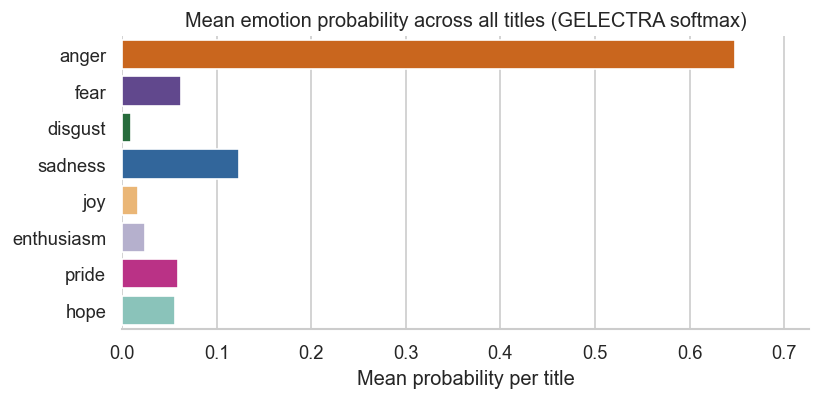

In [9]:
emotion_means = df[EMOTION_COLS].mean()
plot_df = pd.DataFrame({"emotion": EMOTION_SHORT, "mean_prob": emotion_means.values})

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=plot_df,
    x="mean_prob",
    y="emotion",
    hue="emotion",
    dodge=False,
    palette=[emotion_colors[e] for e in plot_df["emotion"]],
    legend=False,
)
plt.title("Mean emotion probability across all titles (GELECTRA softmax)")
plt.xlabel("Mean probability per title")
plt.ylabel("")
plt.xlim(0, plot_df["mean_prob"].max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

### By outlet: heatmap of mean probabilities

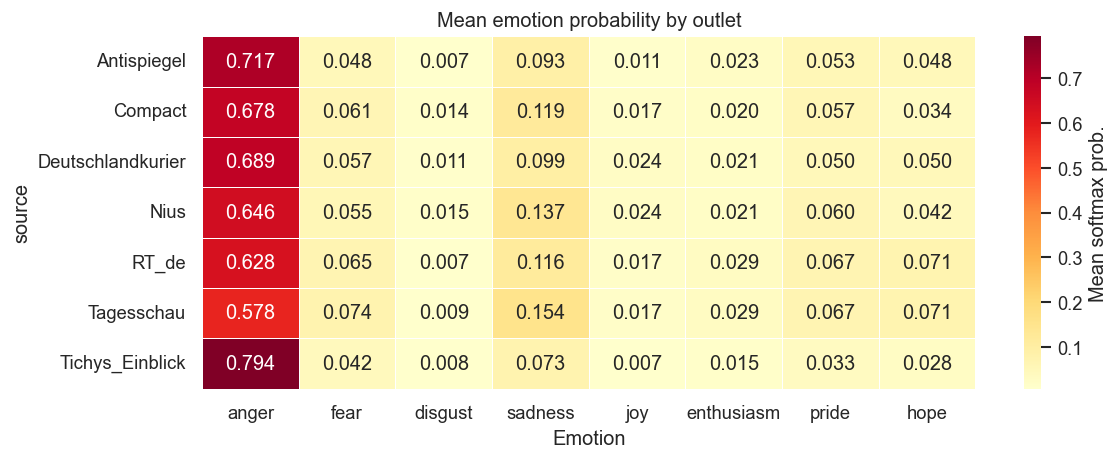

In [10]:
mean_by_outlet = df.groupby(OUTLET_COL, observed=True)[EMOTION_COLS].mean()
mean_by_outlet.columns = EMOTION_SHORT
mean_by_outlet = mean_by_outlet.sort_index()

plt.figure(figsize=(10, max(4, 0.35 * len(mean_by_outlet))))
sns.heatmap(
    mean_by_outlet,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean softmax prob."},
)
plt.title("Mean emotion probability by outlet")
plt.ylabel(OUTLET_COL)
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

### Grouped bars: mean probability per emotion, faceted by outlet

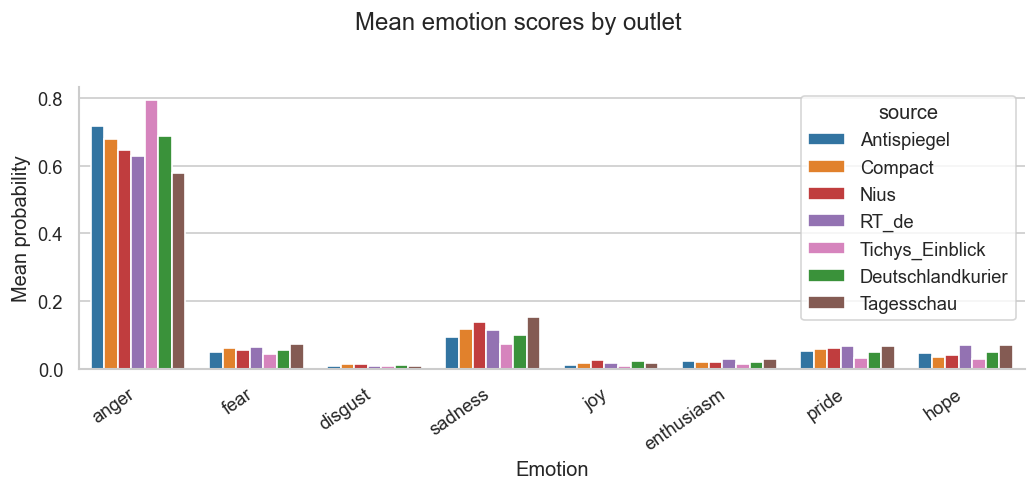

In [11]:
melt_outlet = df.melt(
    id_vars=[OUTLET_COL],
    value_vars=EMOTION_COLS,
    var_name="emotion_col",
    value_name="prob",
)
melt_outlet["emotion"] = melt_outlet["emotion_col"].str.replace("emotion_", "")

g = sns.catplot(
    data=melt_outlet,
    kind="bar",
    x="emotion",
    y="prob",
    hue=OUTLET_COL,
    palette=outlet_colors,
    height=4,
    aspect=2.2,
    legend_out=False,
    errorbar=None,
    estimator="mean",
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Emotion", "Mean probability")
g.figure.suptitle("Mean emotion scores by outlet", y=1.02)
plt.tight_layout()
plt.show()

### Dominant-emotion shares by outlet (%)

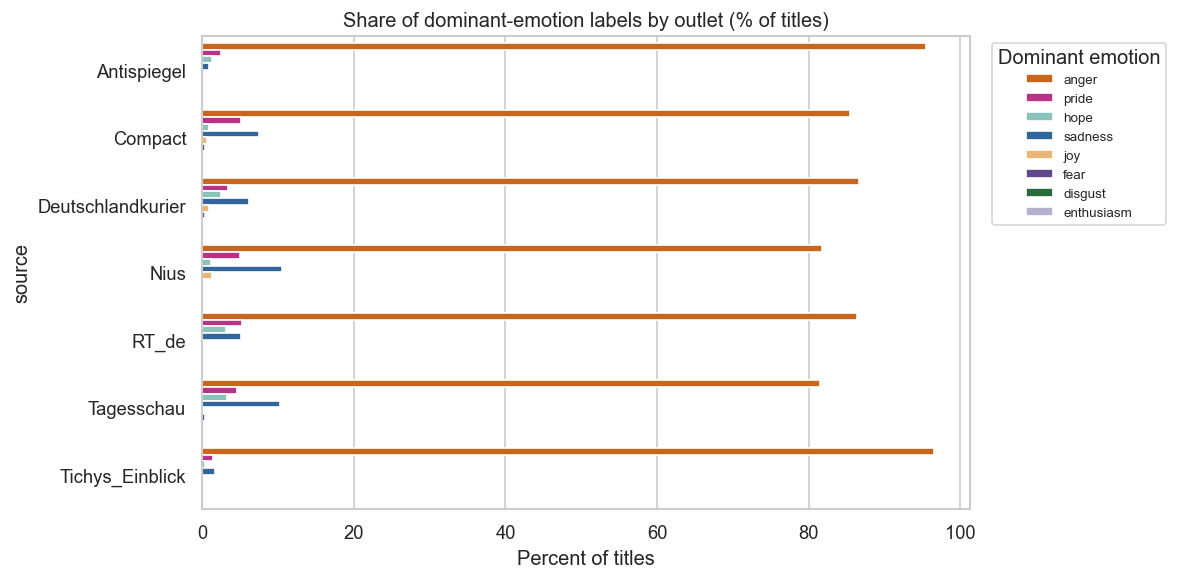

In [13]:
dom_share = (
    df.groupby(OUTLET_COL, observed=True)["emotion_dominant"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dom_share,
    x="pct",
    y=OUTLET_COL,
    hue="emotion_dominant",
    palette=emotion_colors,
    dodge=True,
)
plt.title("Share of dominant-emotion labels by outlet (% of titles)")
plt.xlabel("Percent of titles")
plt.legend(title="Dominant emotion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Example: distribution of **anger** and **fear** by outlet (boxplot)

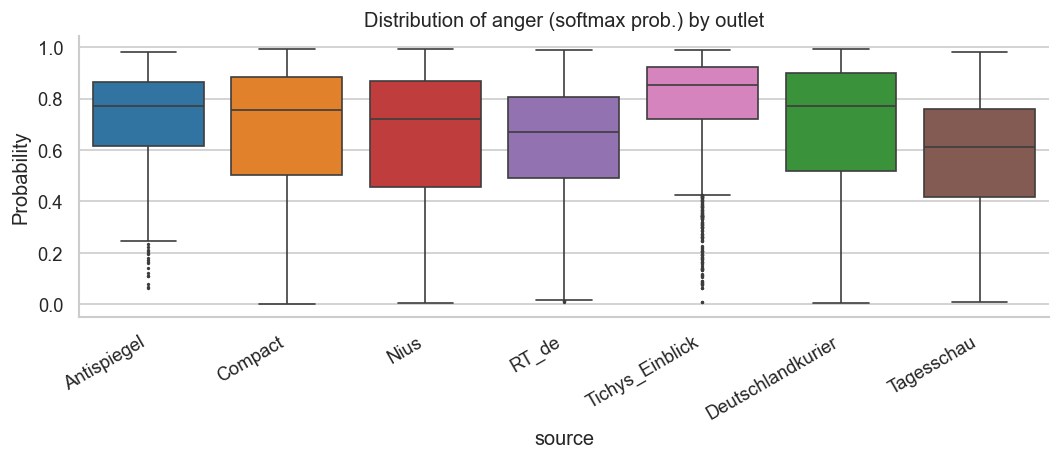

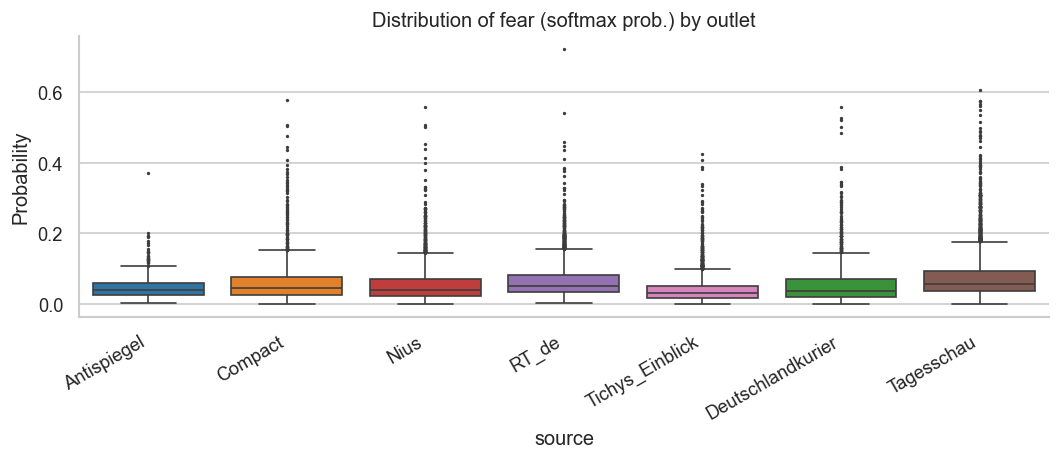

In [15]:
for emo, col in [("anger", "emotion_anger"), ("fear", "emotion_fear")]:
    plt.figure(figsize=(9, 4))
    sns.boxplot(
        data=df,
        x=OUTLET_COL,
        y=col,
        hue=OUTLET_COL,
        palette=outlet_colors,
        dodge=False,
        legend=False,
        fliersize=1,
    )
    plt.title(f"Distribution of {emo} (softmax prob.) by outlet")
    plt.xlabel(OUTLET_COL)
    plt.ylabel("Probability")
    plt.xticks(rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    plt.show()

/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_63186/2086565043.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


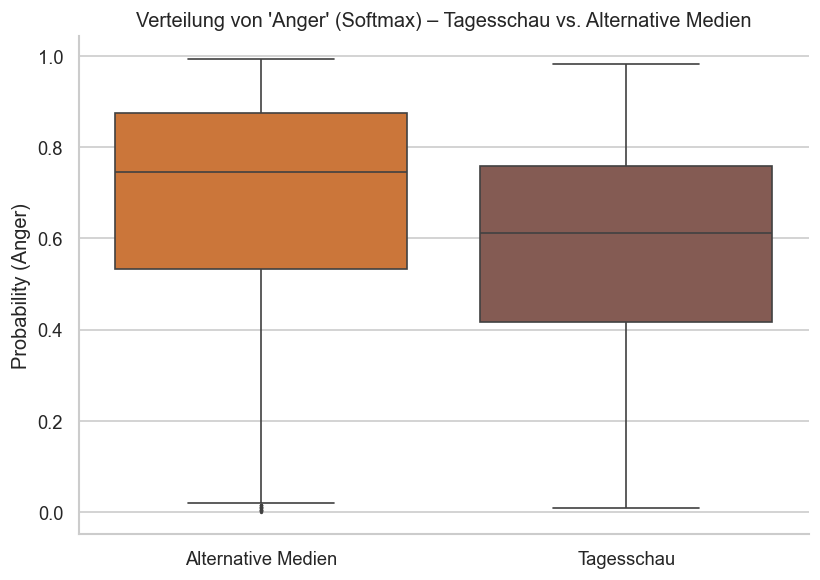

In [16]:
# Combine all alternative outlets vs Tagesschau for anger boxplot

# Define which are the alternative outlets
tagesschau_name = "Tagesschau"
alt_outlets = [o for o in df[OUTLET_COL].unique() if o != tagesschau_name]

# Create a new column for group
df["outlet_group"] = df[OUTLET_COL].apply(lambda x: "Tagesschau" if x == tagesschau_name else "Alternative Medien")

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="outlet_group",
    y="emotion_anger",
    palette={
        "Tagesschau": outlet_colors[tagesschau_name] if tagesschau_name in outlet_colors else "#193b5b",
        "Alternative Medien": "#e37222",
    },
    fliersize=1,
)
plt.title("Verteilung von 'Anger' (Softmax) – Tagesschau vs. Alternative Medien")
plt.xlabel("")
plt.ylabel("Probability (Anger)")
sns.despine()
plt.tight_layout()
plt.show()


In [17]:
is_anger_dom = (df["emotion_dominant"] == "anger").astype(int)
sub = df[df["outlet_group"].isin(["Tagesschau", "Alternative Medien"])].copy()

In [18]:
from scipy import stats

sub["anger_dom"] = sub["emotion_dominant"].eq("anger")
ct = pd.crosstab(sub["outlet_group"], sub["anger_dom"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print("Contingency table:\n", ct)
print("chi2 =", chi2, "p =", p)

# If counts are small:
odds_ratio, p_fisher = stats.fisher_exact(ct)  # 2x2 only
print("Fisher exact p =", p_fisher)

Contingency table:
 anger_dom           False  True 
outlet_group                    
Alternative Medien   1755  12357
Tagesschau           1169   5150
chi2 = 130.36082853090707 p = 3.4166648338880745e-30
Fisher exact p = 2.9349042864678343e-29


In [19]:
a = sub.loc[sub["outlet_group"] == "Tagesschau", "emotion_anger"]
b = sub.loc[sub["outlet_group"] == "Alternative Medien", "emotion_anger"]
stats.mannwhitneyu(a, b, alternative="two-sided")

MannwhitneyuResult(statistic=np.float64(31998500.0), pvalue=np.float64(5.722547030560032e-229))

### Export summary tables (optional)

Saved next to figures for use in the thesis.

In [ ]:
# summary_stats.to_csv(FIG_DIR / "../tables_emotion_summary_stats.csv")
# mean_by_outlet.to_csv(FIG_DIR / "../tables_mean_emotion_by_outlet.csv")
# outlet_summary.to_csv(FIG_DIR / "../tables_outlet_counts.csv", index=False)
# print("Wrote CSV tables to outputs/tables_*.csv")